<a href="https://colab.research.google.com/github/espinozaabigailrosa/Primer-control/blob/main/EVALUACION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import geopandas as gpd
import pandas as pd

In [ ]:
#Importar el archivo
linkGit="https://github.com/CIENCIA-DE-DATOS-ESPACIALES-1IAS21-05A1/EVALUACION-1/raw/main/"
linkMapa="worldMaps.gpkg"

In [ ]:
#Ver las capas disponibles
print(gpd.list_layers(linkGit+linkMapa))

        name    geometry_type
0     rivers  MultiLineString
1     cities            Point
2  countries     MultiPolygon


In [ ]:
#Seleccionamos el nivel y lo cargamos
countries=gpd.read_file(linkGit+linkMapa,layer='countries')
countries

,COUNTRY,geometry
0,Aruba (Netherlands),"MULTIPOLYGON (((-69.88223 12.41111, -69.94695 ..."
1,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ..."
2,Afghanistan,"MULTIPOLYGON (((61.27656 35.60725, 61.29638 35..."
3,Algeria,"MULTIPOLYGON (((-5.15213 30.18047, -5.13917 30..."
4,Azerbaijan,"MULTIPOLYGON (((46.54037 38.87559, 46.49554 38..."
...,...,...
247,South Sudan,"MULTIPOLYGON (((34.21807 9.96458, 34.20722 9.9..."
248,Indonesia,"MULTIPOLYGON (((123.21846 -10.80917, 123.19832..."
249,East Timor,"MULTIPOLYGON (((124.41824 -9.3001, 124.40446 -..."
250,Curacao (Netherlands),"MULTIPOLYGON (((-68.96556 12.19889, -68.91196 ..."


In [ ]:
#Se verifica si existen países duplicados en la columna COUNTRY
countries[countries.duplicated(subset='COUNTRY', keep=False)]

,COUNTRY,geometry


In [ ]:
#Cargar CSV
datos = pd.read_csv(linkGit + 'some_dataworld.csv')
datos

,Country,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,mobiles
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
...,...,...,...,...,...,...,...,...,...,...
167,VENEZUELA,VE,VEN,SOUTH AMERICA,90.0,76730000,912050,509,31250306,18800000
168,VIETNAM,VN,VNM,EAST AND SOUTHEAST ASIA,66.1,249929000,331210,36,105758975,131000000
169,YEMEN,YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
170,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000


In [ ]:
#Cambiar nombre a la columna Country a COUNTRY para que coincidan el CSV y el GeoDataFrame
#Cambiar nombre a la columna mobiles a MOBILES como se solicita en la actividad
datos = datos.rename(columns={
    'Country': 'COUNTRY',
    'mobiles': 'MOBILES'
})
datos

,COUNTRY,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,MOBILES
0,AFGHANISTAN,AF,AFG,SOUTH ASIA,105.0,7893000,652230,68,40121552,23000000
1,ALBANIA,AL,ALB,EUROPE,58.9,3794000,28748,3,3107100,2610000
2,ALGERIA,DZ,DZA,AFRICA,75.4,151633000,2381740,95,47022473,51500000
3,ANGOLA,AO,AGO,AFRICA,87.8,19362000,1246700,107,37202061,25700000
4,ANTIGUA AND BARBUDA,AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
...,...,...,...,...,...,...,...,...,...,...
167,VENEZUELA,VE,VEN,SOUTH AMERICA,90.0,76730000,912050,509,31250306,18800000
168,VIETNAM,VN,VNM,EAST AND SOUTHEAST ASIA,66.1,249929000,331210,36,105758975,131000000
169,YEMEN,YE,YEM,MIDDLE EAST,113.5,10158000,527968,37,32140443,20000000
170,ZAMBIA,ZM,ZMB,AFRICA,85.7,6798000,752618,120,20799116,21200000


In [ ]:
#Se verifica si existen países duplicados en la columna COUNTRY
datos[datos.duplicated(subset='COUNTRY', keep=False)]

,COUNTRY,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,MOBILES


In [ ]:
#Verificar qué países están en uno pero no en el otro
onlyDF = set(datos['COUNTRY']) - set(countries['COUNTRY'])
onlyGDF = set(countries['COUNTRY']) - set(datos['COUNTRY'])

In [ ]:
#Países en el GeoDataFrame pero no en el CSV
onlyGDF

{'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa (US)',
 'American Virgin Islands (US)',
 'Andorra',
 'Angola',
 'Anguilla (UK)',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba (Netherlands)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Baker Island (US)',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda (UK)',
 'Bhutan',
 'Bolivia',
 'Bonaire (Netherlands)',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island (Norway)',
 'Brazil',
 'British Indian Ocean Territory (UK)',
 'British Virgin Islands(UK)',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands (UK)',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island (Australia)',
 'Cocos (Keeling) Islands (Australia)',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands (New Zealand)',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao (Netherlands)',
 'Cyprus',

In [ ]:
#Países en el CSV pero no en el GeoDataFrame
onlyDF

{'AFGHANISTAN',
 'ALBANIA',
 'ALGERIA',
 'ANGOLA',
 'ANTIGUA AND BARBUDA',
 'ARGENTINA',
 'ARMENIA',
 'AUSTRALIA',
 'AUSTRIA',
 'AZERBAIJAN',
 'BAHAMAS (THE)',
 'BAHRAIN',
 'BANGLADESH',
 'BARBADOS',
 'BELARUS',
 'BELGIUM',
 'BELIZE',
 'BENIN',
 'BHUTAN',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BOSNIA AND HERZEGOVINA',
 'BOTSWANA',
 'BRAZIL',
 'BRUNEI DARUSSALAM',
 'BULGARIA',
 'BURKINA FASO',
 'BURUNDI',
 'CABO VERDE',
 'CAMBODIA',
 'CAMEROON',
 'CANADA',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'CHAD',
 'CHILE',
 'CHINA',
 'COLOMBIA',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 'COSTA RICA',
 'CROATIA',
 'CUBA',
 'CYPRUS',
 "CÔTE D'IVOIRE",
 'DENMARK',
 'DJIBOUTI',
 'DOMINICAN REPUBLIC (THE)',
 'ECUADOR',
 'EGYPT',
 'EL SALVADOR',
 'EQUATORIAL GUINEA',
 'ESTONIA',
 'ESWATINI',
 'ETHIOPIA',
 'FIJI',
 'FINLAND',
 'FRANCE',
 'GABON',
 'GAMBIA (THE)',
 'GEORGIA',
 'GERMANY',
 'GHANA',
 'GREECE',
 'GRENADA',
 'GUATEMALA',
 'GUINEA',
 'GUINEA-BISSAU',
 'GUYANA',

In [ ]:
# Instalar thefuzz
!pip install thefuzz
from thefuzz.process import extractOne as best

In [ ]:
#Se crea una tabla para comparar la similitud de nombres
Tabla = pd.DataFrame([
    (COUNTRY, best(COUNTRY,onlyGDF)[0], best(COUNTRY,onlyGDF)[1])
    for COUNTRY in onlyDF
], columns=["DF", "GDF", "SCORE"])
Tabla

,DF,GDF,SCORE
0,MAURITIUS,Mauritius,100
1,GUINEA,Guinea,100
2,GUATEMALA,Guatemala,100
3,THAILAND,Thailand,100
4,ALGERIA,Algeria,100
...,...,...,...
167,CROATIA,Croatia,100
168,MALAWI,Malawi,100
169,PARAGUAY,Paraguay,100
170,MALAYSIA,Malaysia,100


In [ ]:
#Filtrado de nombres con baja coincidencia (menos de 90 puntos) para revisión manual
Tabla[Tabla["SCORE"] < 90]

,DF,GDF,SCORE
17,KOREA (THE REPUBLIC OF),South Georgia and the South Sandwich Is (UK),86
38,CÔTE D'IVOIRE,Israel,60
75,LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE),Central African Republic,86
80,CABO VERDE,Cape Verde,80
108,TIMOR-LESTE,East Timor,81
129,ESWATINI,India,68


In [ ]:
#Verificar si los países existen el GeoDataFrame usando adberviaturas
countries.COUNTRY[countries.COUNTRY.str.contains('Kor|Swaz|Tim|Ivo|Cab|Ver|Lao')]

,COUNTRY
52,Cape Verde
109,Ivory Coast
120,North Korea
122,South Korea
126,Laos
243,Swaziland
249,East Timor


In [ ]:
#Corrección manual de los nombres
manualChanges={'Swaziland':'ESWATINI',
               'South Korea':"KOREA (THE REPUBLIC OF)",
               'East Timor':'TIMOR-LESTE',
               'Cape Verde':'CABO VERDE',
               "Laos":"LAO PEOPLE'S DEMOCRATIC REPUBLIC (THE)",
               "Ivory Coast":"CÔTE D'IVOIRE",
              }
countries.replace(to_replace={'COUNTRY':manualChanges},inplace=True)

In [ ]:
#Recalcular diferencias entre ambos datasets
onlyDF = set(datos['COUNTRY']) - set(countries['COUNTRY'])
onlyGDF = set(countries['COUNTRY']) - set(datos['COUNTRY'])

In [ ]:
#Países del CSV que aún no coinciden con el GeoDataFrame
onlyDF

{'AFGHANISTAN',
 'ALBANIA',
 'ALGERIA',
 'ANGOLA',
 'ANTIGUA AND BARBUDA',
 'ARGENTINA',
 'ARMENIA',
 'AUSTRALIA',
 'AUSTRIA',
 'AZERBAIJAN',
 'BAHAMAS (THE)',
 'BAHRAIN',
 'BANGLADESH',
 'BARBADOS',
 'BELARUS',
 'BELGIUM',
 'BELIZE',
 'BENIN',
 'BHUTAN',
 'BOLIVIA (PLURINATIONAL STATE OF)',
 'BOSNIA AND HERZEGOVINA',
 'BOTSWANA',
 'BRAZIL',
 'BRUNEI DARUSSALAM',
 'BULGARIA',
 'BURKINA FASO',
 'BURUNDI',
 'CAMBODIA',
 'CAMEROON',
 'CANADA',
 'CENTRAL AFRICAN REPUBLIC (THE)',
 'CHAD',
 'CHILE',
 'CHINA',
 'COLOMBIA',
 'COMOROS (THE)',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)',
 'CONGO (THE)',
 'COSTA RICA',
 'CROATIA',
 'CUBA',
 'CYPRUS',
 'DENMARK',
 'DJIBOUTI',
 'DOMINICAN REPUBLIC (THE)',
 'ECUADOR',
 'EGYPT',
 'EL SALVADOR',
 'EQUATORIAL GUINEA',
 'ESTONIA',
 'ETHIOPIA',
 'FIJI',
 'FINLAND',
 'FRANCE',
 'GABON',
 'GAMBIA (THE)',
 'GEORGIA',
 'GERMANY',
 'GHANA',
 'GREECE',
 'GRENADA',
 'GUATEMALA',
 'GUINEA',
 'GUINEA-BISSAU',
 'GUYANA',
 'HAITI',
 'HONDURAS',
 'HUNGARY',
 'ICELAND'

In [ ]:
#Países del GeoDataFrame que aún no coinciden con el CSV
onlyGDF

{'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa (US)',
 'American Virgin Islands (US)',
 'Andorra',
 'Angola',
 'Anguilla (UK)',
 'Antarctica',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba (Netherlands)',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Baker Island (US)',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda (UK)',
 'Bhutan',
 'Bolivia',
 'Bonaire (Netherlands)',
 'Bosnia and Herzegovina',
 'Botswana',
 'Bouvet Island (Norway)',
 'Brazil',
 'British Indian Ocean Territory (UK)',
 'British Virgin Islands(UK)',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cayman Islands (UK)',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Christmas Island (Australia)',
 'Cocos (Keeling) Islands (Australia)',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands (New Zealand)',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao (Netherlands)',
 'Cyprus',
 'Czech Republ

In [ ]:
#Verificar las coincidencias tras el matching manual, se esperan puntajes mayores o iguales a 90
pd.DataFrame([(COUNTRY, best(COUNTRY,onlyGDF)[0],best(COUNTRY,onlyGDF)[1]) for COUNTRY in onlyDF]).sort_values(2)

,0,1,2
24,BAHAMAS (THE),Bahamas,90
55,CONGO (THE),Congo,90
39,GAMBIA (THE),Gambia,90
33,MOLDOVA (THE REPUBLIC OF),Moldova,90
90,SAMOA,Western Samoa,90
...,...,...,...
160,SOLOMON ISLANDS,Solomon Islands,100
162,MALAWI,Malawi,100
161,CROATIA,Croatia,100
163,PARAGUAY,Paraguay,100


In [ ]:
#Crear diccionario para corrección de nombres
changesToDF={COUNTRY: best(COUNTRY,onlyGDF)[0] for COUNTRY in onlyDF}
changesToDF

{'MAURITIUS': 'Mauritius',
 'GUINEA': 'Guinea',
 'GUATEMALA': 'Guatemala',
 'THAILAND': 'Thailand',
 'ALGERIA': 'Algeria',
 'PERU': 'Peru',
 'DENMARK': 'Denmark',
 'CHINA': 'China',
 'SLOVENIA': 'Slovenia',
 'ZAMBIA': 'Zambia',
 'MALI': 'Mali',
 'BURKINA FASO': 'Burkina Faso',
 'POLAND': 'Poland',
 'UGANDA': 'Uganda',
 'INDIA': 'India',
 'SENEGAL': 'Senegal',
 'NIGERIA': 'Nigeria',
 'TUNISIA': 'Tunisia',
 'SRI LANKA': 'Sri Lanka',
 'SAUDI ARABIA': 'Saudi Arabia',
 'TOGO': 'Togo',
 'FRANCE': 'France',
 'NORWAY': 'Norway',
 'LITHUANIA': 'Lithuania',
 'BAHAMAS (THE)': 'Bahamas',
 'SAO TOME AND PRINCIPE': 'Sao Tome and Principe',
 'ROMANIA': 'Romania',
 'NEW ZEALAND': 'New Zealand',
 'PHILIPPINES (THE)': 'Philippines',
 'ALBANIA': 'Albania',
 'UKRAINE': 'Ukraine',
 'ITALY': 'Italy',
 'AUSTRALIA': 'Australia',
 'MOLDOVA (THE REPUBLIC OF)': 'Moldova',
 'CONGO (THE DEMOCRATIC REPUBLIC OF THE)': 'Democratic Republic of the Congo',
 'GRENADA': 'Grenada',
 'BOSNIA AND HERZEGOVINA': 'Bosnia and H

In [ ]:
#Aplicar corrección de nombres al dataset
datos.replace(to_replace={'COUNTRY': changesToDF}, inplace=True)

In [ ]:
#Revisar que ya no queden coincidencias de nombres entre ambos datasets
onlyDF = set(datos['COUNTRY']) - set(countries['COUNTRY'])
onlyGDF = set(countries['COUNTRY']) - set(datos['COUNTRY'])
pd.DataFrame([(COUNTRY, best(COUNTRY,onlyGDF)[0],best(COUNTRY,onlyGDF)[1]) for COUNTRY in onlyDF])

""


In [ ]:
#Unir el GeoDataFrame con el CSV usando la columna COUNTRY
theMapAndData = countries.merge(datos, on="COUNTRY")

In [ ]:
#Filtrar países de América (Norte, Sur, Centroamérica y el Caribe)
america = theMapAndData[
    theMapAndData['region'].isin([
        'NORTH AMERICA',
        'SOUTH AMERICA',
        'CENTRAL AMERICA AND THE CARIBBEAN'
    ])
]

In [ ]:
theMapAndData.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   COUNTRY       172 non-null    object  
 1   geometry      172 non-null    geometry
 2   iso2          171 non-null    object  
 3   iso3          172 non-null    object  
 4   region        172 non-null    object  
 5   fragility     172 non-null    float64 
 6   co2           172 non-null    int64   
 7   sq_km         172 non-null    int64   
 8   num_airports  172 non-null    int64   
 9   population    172 non-null    int64   
 10  MOBILES       172 non-null    int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 14.9+ KB


In [ ]:
america.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 161
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   COUNTRY       31 non-null     object  
 1   geometry      31 non-null     geometry
 2   iso2          31 non-null     object  
 3   iso3          31 non-null     object  
 4   region        31 non-null     object  
 5   fragility     31 non-null     float64 
 6   co2           31 non-null     int64   
 7   sq_km         31 non-null     int64   
 8   num_airports  31 non-null     int64   
 9   population    31 non-null     int64   
 10  MOBILES       31 non-null     int64   
dtypes: float64(1), geometry(1), int64(5), object(4)
memory usage: 2.9+ KB


In [ ]:
#Visualización de los datasets unificado y filtrado para América
america

,COUNTRY,geometry,iso2,iso3,region,fragility,co2,sq_km,num_airports,population,MOBILES
0,Antigua and Barbuda,"MULTIPOLYGON (((-61.73889 17.54055, -61.75195 ...",AG,ATG,CENTRAL AMERICA AND THE CARIBBEAN,54.4,729000,443,4,102634,184000
7,Argentina,"MULTIPOLYGON (((-71.01648 -36.47591, -70.98195...",AR,ARG,SOUTH AMERICA,46.0,193205000,2780400,764,46994384,62700000
11,Barbados,"MULTIPOLYGON (((-59.53306 13.05055, -59.54542 ...",BB,BRB,CENTRAL AMERICA AND THE CARIBBEAN,48.0,1703000,430,1,304139,323000
14,Bahamas,"MULTIPOLYGON (((-77.95029 26.89778, -77.91695 ...",BS,BHS,CENTRAL AMERICA AND THE CARIBBEAN,48.8,3984000,13880,54,410862,400000
16,Belize,"MULTIPOLYGON (((-88.28914 17.1225, -88.28001 1...",BZ,BLZ,CENTRAL AMERICA AND THE CARIBBEAN,62.5,541000,22966,27,415789,264000
18,Bolivia,"MULTIPOLYGON (((-62.19884 -20.47139, -62.26945...",BO,BOL,SOUTH AMERICA,72.9,17786000,1098581,201,12311974,12000000
22,Brazil,"MULTIPOLYGON (((-70.62862 -9.94849, -70.62889 ...",BR,BRA,SOUTH AMERICA,71.8,456670000,8515770,5297,220051512,213000000
27,Canada,"MULTIPOLYGON (((-84.47945 77.29443, -84.46764 ...",CA,CAN,NORTH AMERICA,20.0,612084000,9984670,1459,38794813,36500000
34,Chile,"MULTIPOLYGON (((-73.61806 -51.6339, -73.60494 ...",CL,CHL,SOUTH AMERICA,38.9,88333000,756102,379,18664652,26700000
37,Colombia,"MULTIPOLYGON (((-81.71306 12.49028, -81.72014 ...",CO,COL,SOUTH AMERICA,75.7,81007000,1138910,661,49588357,87400000


In [ ]:
#Guardar datasets en formato GeoJSON
theMapAndData.to_file("worldindicators.json")
america.to_file("america_mobiles.geojson")

**DDM (Dot Density Map)**

In [ ]:
justDots = america.copy()

dot_value = 500000   #1 punto representa 500000 móviles

justDots['num_dots'] = (justDots['MOBILES'] / dot_value).astype(int)

#ubicación de puntos
justDots = justDots.sample_points(size=justDots['num_dots']).explode(index_parts=True)
justDots

7    0      POINT (-72.0528 -50.76383)
     1      POINT (-71.4376 -46.76974)
     2     POINT (-71.15809 -40.89067)
     3     POINT (-70.96938 -50.49453)
     4     POINT (-70.93619 -39.76725)
                      ...             
161  32      POINT (-62.25365 5.08253)
     33      POINT (-61.52831 5.74194)
     34       POINT (-61.46839 4.8707)
     35       POINT (-61.37848 5.9726)
     36       POINT (-61.01487 4.8991)
Name: sampled_points, Length: 2289, dtype: geometry

In [ ]:
type(justDots)

geopandas.geoseries.GeoSeries

In [ ]:
#Limpieza de índice y creación del GeoDataFrame de puntos
justDots.reset_index(drop=True, inplace=True)
america_dots=gpd.GeoDataFrame(geometry=justDots)
america_dots

,geometry
0,POINT (-72.0528 -50.76383)
1,POINT (-71.4376 -46.76974)
2,POINT (-71.15809 -40.89067)
3,POINT (-70.96938 -50.49453)
4,POINT (-70.93619 -39.76725)
...,...
2284,POINT (-62.25365 5.08253)
2285,POINT (-61.52831 5.74194)
2286,POINT (-61.46839 4.8707)
2287,POINT (-61.37848 5.9726)


In [ ]:
#Reproyección de los datasets a EPSG:6933
america_6933=america.to_crs(6933)
america_dots_6933=america_dots.to_crs(6933)

<Axes: >

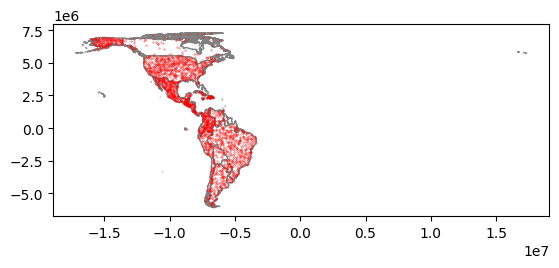

In [ ]:
# Creación del Dot Density Map (DDM)
base=america_6933.plot(facecolor="white",#color of polygon fill
                      edgecolor='grey') #color of border
america_dots_6933.plot(markersize=0.06, color='red',ax=base)

**PSM (Proportional Symbol Map)**

In [ ]:
#Cálculo de centroides de los países
america_6933_Centroides=america_6933.copy()
america_6933_Centroides['geometry'] = america_6933_Centroides['geometry'].centroid

In [ ]:
#Se calcula el tamaño de los puntos aplicando una raíz cuadrada a la población para mejorar la visualización
america_6933_Centroides['size'] = america_6933_Centroides['MOBILES'].apply(lambda x: x**0.5/350)

<Axes: >

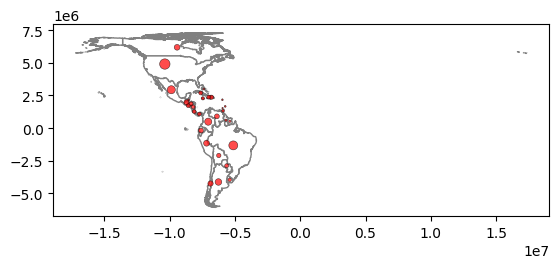

In [ ]:
# Creación del Proportional Symbol Map (PSM)
base = america_6933.plot(
    facecolor="white",
    edgecolor='grey'
)

america_6933_Centroides.plot(
    ax=base,
    markersize=america_6933_Centroides['size'],
    color='red',          # cambia el color
    edgecolor='black',    # contorno
    linewidth=0.4,        # grosor del borde
    alpha=0.7             # transparencia
)

**Choropleth**

In [ ]:
#Calculamos el área y la densidad
america_6933['area_km2'] = america_6933.geometry.area / 1_000_000
america_6933['densidad'] = america_6933['MOBILES'] / america_6933['area_km2']

In [ ]:
#Instalación de la librería mapclassify
!pip install mapclassify

In [ ]:
#Clasificación de la densidad usando el método Fisher-Jenks
import mapclassify
import numpy as np

#Usamos log1p en la densidad para que se noten mejor las diferencias sin alterar los datos
theVar = np.log1p(america_6933['densidad'])
K = 4
fj5 = mapclassify.FisherJenks(theVar, k=K)
america_6933['densidad_cat'] = fj5.yb

In [ ]:
#Asignar nombres a los niveles numéricos de densidad
newLabelsForLevels = {0: "0_Muy baja",
                       1: "1_Baja",
                       2: "2_Media",
                       3: "3_Alta"}
america_6933['densidad_cat_nombre'] = america_6933['densidad_cat'].replace(newLabelsForLevels)

In [ ]:
print(america_6933[['COUNTRY', 'densidad', 'densidad_cat', 'densidad_cat_nombre']].head(35))

                 COUNTRY    densidad  densidad_cat densidad_cat_nombre
0    Antigua and Barbuda  342.716410             3              3_Alta
7              Argentina   22.546134             1              1_Baja
11              Barbados  723.742595             3              3_Alta
14               Bahamas   32.957277             1              1_Baja
16                Belize   11.982192             0          0_Muy baja
18               Bolivia   11.044455             0          0_Muy baja
22                Brazil   25.140832             1              1_Baja
27                Canada    3.667237             0          0_Muy baja
34                 Chile   35.870239             1              1_Baja
37              Colombia   76.997578             2             2_Media
39            Costa Rica  145.736279             2             2_Media
41                  Cuba   70.243840             2             2_Media
46    Dominican Republic  215.017368             3              3_Alta
47    

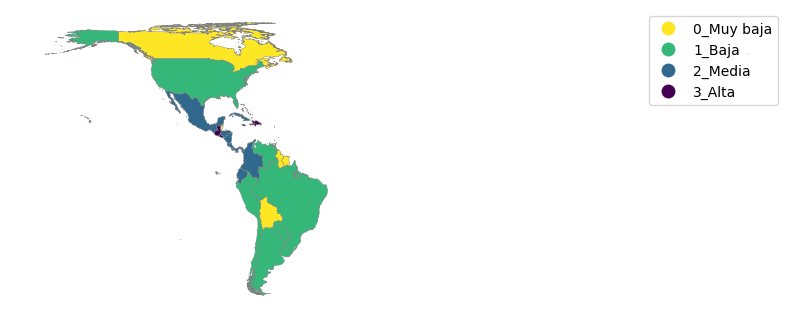

In [ ]:
#Creación del mapa coroplético (choropleth)
import matplotlib.pyplot as plt

f, ax = plt.subplots(1, figsize=(10, 10))

america_6933.plot(
    column='densidad_cat_nombre',
    cmap='viridis_r',
    categorical=True,
    edgecolor='grey',
    linewidth=0.3,
    legend=True,
    ax=ax
)

ax.set_axis_off()

In [ ]:
#Revisar GeoDataFrames disponibles
geodataframe_list = [var for var in globals() if isinstance(globals()[var], gpd.GeoDataFrame)]
print("List of GeoDataFrames in memory:")
for name in geodataframe_list:
    print(name)

List of GeoDataFrames in memory:
___
countries
_31
_32
theMapAndData
america
_55
america_dots
_59
america_6933
america_dots_6933
america_6933_Centroides


In [ ]:
america_6933.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 161
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   COUNTRY              31 non-null     object  
 1   geometry             31 non-null     geometry
 2   iso2                 31 non-null     object  
 3   iso3                 31 non-null     object  
 4   region               31 non-null     object  
 5   fragility            31 non-null     float64 
 6   co2                  31 non-null     int64   
 7   sq_km                31 non-null     int64   
 8   num_airports         31 non-null     int64   
 9   population           31 non-null     int64   
 10  MOBILES              31 non-null     int64   
 11  area_km2             31 non-null     float64 
 12  densidad             31 non-null     float64 
 13  densidad_cat         31 non-null     int64   
 14  densidad_cat_nombre  31 non-null     object  
dtypes: float64(3), geomet

In [ ]:
america_dots_6933.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2289 entries, 0 to 2288
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   geometry  2289 non-null   geometry
dtypes: geometry(1)
memory usage: 18.0 KB


In [ ]:
america_6933_Centroides.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 31 entries, 0 to 161
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   COUNTRY       31 non-null     object  
 1   geometry      31 non-null     geometry
 2   iso2          31 non-null     object  
 3   iso3          31 non-null     object  
 4   region        31 non-null     object  
 5   fragility     31 non-null     float64 
 6   co2           31 non-null     int64   
 7   sq_km         31 non-null     int64   
 8   num_airports  31 non-null     int64   
 9   population    31 non-null     int64   
 10  MOBILES       31 non-null     int64   
 11  size          31 non-null     float64 
dtypes: float64(2), geometry(1), int64(5), object(4)
memory usage: 3.1+ KB


In [ ]:
#Guardar mapas para R
america_6933.to_file("america_6933.gpkg", driver='GPKG', layer='MOBILES_densidad')
america_dots_6933.to_file("america_6933.gpkg", driver='GPKG', layer='puntos_ddm')
america_6933_Centroides.to_file ("america_6933.gpkg", driver='GPKG', layer='centroides_psm')